### Baseline Model

The current model serves as a baseline for stock prediction.  
It uses the previous day's closing price as the only feature to predict the next day's price.

Feature used:

Prev_Close = Close.shift(1)

This means the model is essentially learning:

Close_today ≈ Close_yesterday

Because stock prices tend to move smoothly from day to day, the predicted values often closely track the actual values. This baseline helps establish a reference point that future models must outperform.

### TODO
- Implement a Ridge Regression model (alpha = 1)
- Standardize features before training
- Add additional lag features (Lag2, Lag3, Lag5)
- Add moving average features (MA5, MA20)
- Evaluate model improvements against the baseline

In [2]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import numpy as np

In [6]:
df = pd.read_csv("../data/RBLX.csv", skiprows=2)

df.columns = ["Date","Close","High","Low","Open","Volume"]

df["Close"] = pd.to_numeric(df["Close"])

df.head()

,Date,Close,High,Low,Open,Volume
0,2021-03-10,69.500000,74.830002,60.500000,64.500000,97069300
1,2021-03-11,73.900002,77.779999,70.129997,74.930000,59629300
2,2021-03-12,69.699997,72.959999,69.110001,72.470001,19714700
3,2021-03-15,72.150002,74.059998,66.250000,70.019997,19549800
4,2021-03-16,77.000000,78.000000,73.180000,73.730003,30274400


In [7]:
df["Prev_Close"] = df["Close"].shift(1)

df = df.dropna()

X = df[["Prev_Close"]]
y = df["Close"]

df.head()

,Date,Close,High,Low,Open,Volume,Prev_Close
1,2021-03-11,73.900002,77.779999,70.129997,74.930000,59629300,69.500000
2,2021-03-12,69.699997,72.959999,69.110001,72.470001,19714700,73.900002
3,2021-03-15,72.150002,74.059998,66.250000,70.019997,19549800,69.699997
4,2021-03-16,77.000000,78.000000,73.180000,73.730003,30274400,72.150002
5,2021-03-17,76.790001,79.099998,74.889999,76.029999,10054100,77.000000


In [8]:
model = joblib.load("../models/model.pkl")

preds = model.predict(X)

preds[:10]

array([69.33899157, 73.70268237, 69.53733806, 71.96712413, 76.77709831,
       76.56883223, 67.15714995, 70.33073914, 69.83486535, 67.85137022])

In [9]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

preds_test = model.predict(X_test)

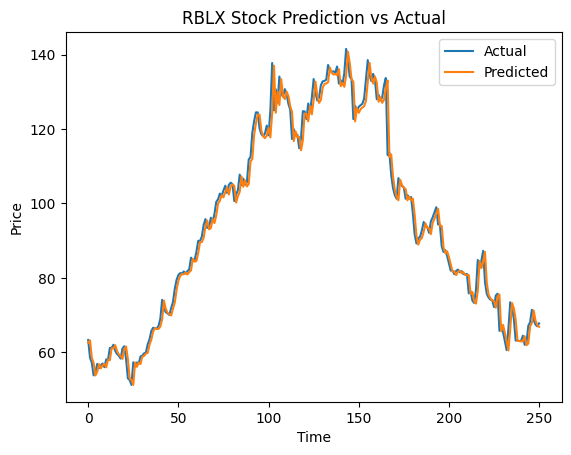

In [10]:
plt.figure()

plt.plot(y_test.values, label="Actual")
plt.plot(preds_test, label="Predicted")

plt.legend()
plt.title("RBLX Stock Prediction vs Actual")
plt.xlabel("Time")
plt.ylabel("Price")

plt.show()

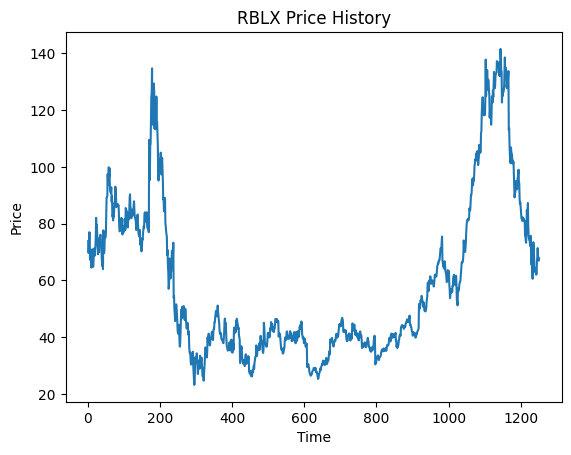

In [11]:
plt.figure()

plt.plot(df["Close"])

plt.title("RBLX Price History")
plt.xlabel("Time")
plt.ylabel("Price")

plt.show()

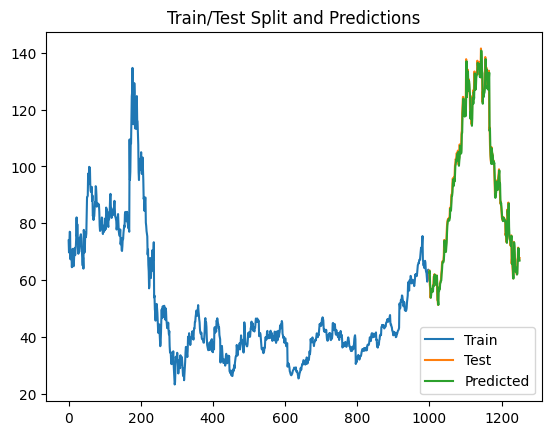

In [12]:
plt.figure()

plt.plot(range(len(y_train)), y_train, label="Train")
plt.plot(range(len(y_train), len(y_train)+len(y_test)), y_test, label="Test")
plt.plot(range(len(y_train), len(y_train)+len(preds_test)), preds_test, label="Predicted")

plt.legend()
plt.title("Train/Test Split and Predictions")

plt.show()